# Part 6 — Evaluation, Backtesting & Baselines

**Series:** *Time Series Analysis in Python — from Statistical Modeling to Machine Learning*

For five parts we have quietly leaned on a **single train/test split** — the last
24 months — and every time the story was the same: nothing beat the drift
baseline. This part reveals *why that verdict was unreliable*, and builds the
rigorous evaluation machinery every later part depends on. It is the least
glamorous and most important notebook in the series: **a model is only as
trustworthy as the procedure used to score it.**

### What you will learn
1. Why a **single split is fragile**, and the discipline that fixes it
2. The **baselines** you must always beat, and why they anchor good metrics
3. The full **metric zoo** — MAE, RMSE, MAPE, sMAPE, **MASE**, and **pinball loss**
4. **Time-series cross-validation** — expanding vs. sliding windows, walk-forward backtesting
5. **Leakage traps** that silently invalidate results
6. **Multi-step strategies** — recursive, direct, DirRec — the bridge to the ML parts

### Dataset & continuity
Still `monthly_price.csv` (356 months, 1992–2021), forecasting the **Food Price
Index**. New libraries: `scikit-learn` (`TimeSeriesSplit`) and `sktime`.

## 0. Setup and a small stable of forecasters

To study *evaluation*, we need a few models to evaluate. We wrap five familiar
forecasters from Parts 3–4 as simple functions `f(train, h) -> array` so we can
score them uniformly.

In [1]:
import warnings, logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch

warnings.simplefilter("ignore")
from sklearn.model_selection import TimeSeriesSplit, KFold
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.exponential_smoothing.ets import ETSModel
from statsmodels.tsa.arima.model import ARIMA

plt.rcParams.update({
    "figure.figsize": (11, 4.2), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.3,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 13, "axes.titleweight": "bold",
    "font.size": 11, "lines.linewidth": 1.6,
})
PALETTE = ["#2b6cb0", "#c05621", "#2f855a", "#6b46c1", "#b83280", "#718096"]

raw = pd.read_csv("monthly_price.csv")
dates = pd.to_datetime(raw["YEAR"].astype(str) + "-" + raw["MONTH"], format="%Y-%b")
df = raw.drop(columns=["ID", "YEAR", "MONTH", "TIME"]).copy()
df.index = dates; df.index.name = "date"; df = df.asfreq("MS")
y = df["Food_Price_Index"]

def f_naive(tr, h):  return np.repeat(tr.iloc[-1], h)
def f_snaive(tr, h, m=12): return np.tile(tr.iloc[-m:].values, int(np.ceil(h/m)))[:h]
def f_drift(tr, h):
    slope = (tr.iloc[-1] - tr.iloc[0]) / (len(tr) - 1)
    return tr.iloc[-1] + slope * np.arange(1, h + 1)
def f_ets(tr, h):
    return ETSModel(tr, error="mul", trend="add", damped_trend=True,
                    initialization_method="estimated").fit(disp=False).forecast(h).values
def f_arima(tr, h):
    return ARIMA(tr, order=(1, 1, 0)).fit().get_forecast(h).predicted_mean.values

FORECASTERS = {"Naive": f_naive, "SeasonalNaive": f_snaive,
               "Drift": f_drift, "ETS": f_ets, "ARIMA": f_arima}
print("forecasters ready:", list(FORECASTERS))

forecasters ready: ['Naive', 'SeasonalNaive', 'Drift', 'ETS', 'ARIMA']


## 1. The problem with a single split

The score from one train/test split is a **sample of size one**. Time series are
non-stationary, so *which* window you test on can dominate the result. To show how
severe this is, we score the **same ETS model** on several different 12-month
windows.

In [2]:
windows = ["2014-12", "2015-12", "2016-12", "2017-12", "2018-12", "2019-12", "2020-12", "2021-08"]
h = 12
rows = []
for w in windows:
    cut = y.index.get_loc(pd.Timestamp(w + "-01")) + 1
    tr, te = y.iloc[:cut - h], y.iloc[cut - h:cut]
    rmse = np.sqrt(np.mean((te.values - f_ets(tr, h)) ** 2))
    rows.append({"window ends": w, "ETS RMSE": round(rmse, 2)})
frag = pd.DataFrame(rows)
frag

,window ends,ETS RMSE
0,2014-12,4.80
1,2015-12,10.47
2,2016-12,8.40
3,2017-12,1.51
4,2018-12,5.04
5,2019-12,2.24
6,2020-12,7.11
7,2021-08,20.98


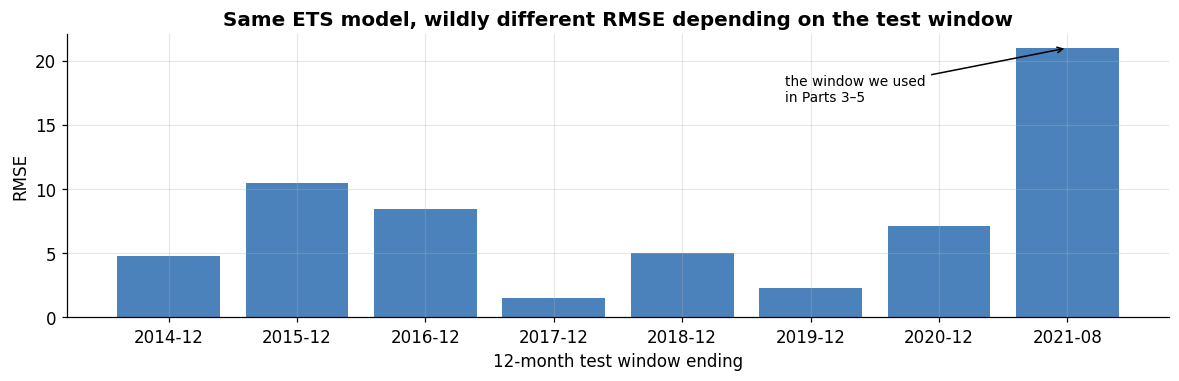

In [3]:
fig, ax = plt.subplots(figsize=(11, 3.6))
ax.bar(frag["window ends"], frag["ETS RMSE"], color=PALETTE[0], alpha=0.85)
ax.set_title("Same ETS model, wildly different RMSE depending on the test window")
ax.set_ylabel("RMSE"); ax.set_xlabel("12-month test window ending")
worst = frag.loc[frag["ETS RMSE"].idxmax()]
ax.annotate("the window we used\nin Parts 3–5", xy=(len(frag)-1, worst["ETS RMSE"]),
            xytext=(len(frag)-3.2, worst["ETS RMSE"]*0.8),
            arrowprops=dict(arrowstyle="->", color="black"), fontsize=9)
plt.tight_layout(); plt.show()

The identical model swings from an RMSE around **1.5** on a calm window to
roughly **21** on the 2020–21 window — an order-of-magnitude difference driven
entirely by *when* we tested. Parts 3–5 happened to use the hardest window on the
whole record, which is exactly why every model there looked barely better than
naive. **No single split can be trusted**; we need to average performance over
many windows. That is cross-validation for time series.

## 2. Baselines — the hurdle every model must clear

Before metrics and CV, fix the **reference points**. A forecast's number means
nothing in isolation; it only matters *relative to something trivial*:

- **Naive** — repeat the last value ("no change").
- **Seasonal naive** — repeat the value from one season (12 months) ago.
- **Drift** — extend the straight line from first to last training point.
- **Mean** — the historical average (rarely competitive, but a floor).

If a complex model can't beat these, it has not earned its complexity — and, as
we'll see, the best baseline also becomes the **denominator** of the most useful
metric (MASE). Baselines aren't a formality; they are the measuring stick.

## 3. The metric zoo

No single number captures forecast quality. Each metric answers a different
question and has different failure modes. We implement them from scratch.

### 3.1 Scale-dependent errors: MAE and RMSE

$$\text{MAE}=\frac{1}{n}\sum|y-\hat y|, \qquad
  \text{RMSE}=\sqrt{\frac{1}{n}\sum (y-\hat y)^2}$$

Both are in the **units of the series**, so they're intuitive but **can't be
compared across series** of different scale. RMSE penalizes large errors more (it
squares them), so it's the choice when big misses are especially costly; MAE is
more robust to outliers.

In [4]:
def mae(a, p):  a,p=np.asarray(a),np.asarray(p); return np.mean(np.abs(a - p))
def rmse(a, p): a,p=np.asarray(a),np.asarray(p); return np.sqrt(np.mean((a - p) ** 2))

### 3.2 Percentage errors: MAPE and sMAPE

$$\text{MAPE}=\frac{100}{n}\sum\left|\frac{y-\hat y}{y}\right|,\qquad
  \text{sMAPE}=\frac{100}{n}\sum\frac{|y-\hat y|}{(|y|+|\hat y|)/2}$$

MAPE is **scale-free** (a %), which aids comparison — but it is **undefined at
y=0**, explodes for small y, and is **asymmetric**: because it divides by the
*actual*, an under-forecast can cost at most 100% (forecast down to zero) while an
over-forecast is unbounded, so MAPE-optimal forecasts are biased low. **sMAPE**
symmetrizes the denominator and is bounded on both sides, though it has quirks of
its own.

In [5]:
def mape(a, p):  a,p=np.asarray(a),np.asarray(p); return 100*np.mean(np.abs((a-p)/a))
def smape(a, p): a,p=np.asarray(a),np.asarray(p); return 100*np.mean(np.abs(a-p)/((np.abs(a)+np.abs(p))/2))

# MAPE's real asymmetry: it divides by the ACTUAL, so under-forecasting is capped
# at 100% (forecast down to 0) while over-forecasting is unbounded.
print("actual = 100, vary the forecast:")
for fc in [0, 50, 80, 120, 200, 300]:
    print(f"  forecast = {fc:3d}:  MAPE = {mape([100],[fc]):3.0f}%   "
          f"sMAPE = {smape([100],[fc]):3.0f}%")
print("\nUnder-forecasting to 0 tops out at MAPE 100%, but a 3× over-forecast is 200%.")
print("That asymmetry quietly biases MAPE-optimal forecasts LOW; sMAPE bounds both sides.")

# scale sensitivity: the SAME absolute error costs more on a small actual
print("\nSame absolute error of 20, different actual levels:")
for a in [40, 100, 200]:
    print(f"  actual = {a:3d}, error 20:  MAPE = {mape([a],[a-20]):.0f}%")

actual = 100, vary the forecast:
  forecast =   0:  MAPE = 100%   sMAPE = 200%
  forecast =  50:  MAPE =  50%   sMAPE =  67%
  forecast =  80:  MAPE =  20%   sMAPE =  22%
  forecast = 120:  MAPE =  20%   sMAPE =  18%
  forecast = 200:  MAPE = 100%   sMAPE =  67%
  forecast = 300:  MAPE = 200%   sMAPE = 100%

Under-forecasting to 0 tops out at MAPE 100%, but a 3× over-forecast is 200%.
That asymmetry quietly biases MAPE-optimal forecasts LOW; sMAPE bounds both sides.

Same absolute error of 20, different actual levels:
  actual =  40, error 20:  MAPE = 50%
  actual = 100, error 20:  MAPE = 20%
  actual = 200, error 20:  MAPE = 10%


### 3.3 The recommended default: MASE

**MASE** (Mean Absolute Scaled Error) divides the model's MAE by the MAE of a
**naive forecast computed in-sample** — usually the seasonal-naive one-step error
on the training data:

$$\text{MASE}=\frac{\text{MAE}_\text{model}}
   {\frac{1}{n-m}\sum_{t=m+1}^{n}|y_t-y_{t-m}|}$$

This makes it **scale-free *and* interpretable**: **MASE < 1** means the model
beats the naive benchmark; **MASE > 1** means it's worse. It's defined everywhere
(no divide-by-zero), comparable across series, and is the metric Hyndman
recommends as a default.

In [6]:
def mase(actual, pred, train, m=12):
    denom = np.mean(np.abs(train.values[m:] - train.values[:-m]))  # in-sample seasonal naive
    return mae(actual, pred) / denom

### 3.4 Probabilistic forecasts: pinball (quantile) loss

Point metrics ignore uncertainty. The **pinball loss** scores a **quantile**
forecast $\hat q_\tau$ against the outcome, penalizing under- and over-prediction
asymmetrically according to the target quantile τ:

$$L_\tau(y,\hat q_\tau)=\begin{cases}\tau\,(y-\hat q_\tau) & y\ge \hat q_\tau\\
(1-\tau)(\hat q_\tau-y) & y<\hat q_\tau\end{cases}$$

Averaged over several quantiles it rewards **well-calibrated intervals**, not just
a good centre — the right metric when the whole predictive distribution matters
(risk, inventory, capacity).

In [7]:
def pinball(actual, q_pred, tau):
    actual, q_pred = np.asarray(actual), np.asarray(q_pred)
    diff = actual - q_pred
    return np.mean(np.maximum(tau * diff, (tau - 1) * diff))

# quantile forecasts from ARIMA's normal predictive distribution on one window
cut = len(y); tr, te = y.iloc[:cut-h], y.iloc[cut-h:cut]
res = ARIMA(tr, order=(1,1,0)).fit().get_forecast(h)
mean, se = res.predicted_mean.values, res.se_mean.values
from scipy.stats import norm
taus = [0.1, 0.5, 0.9]
pin = {f"τ={t}": round(pinball(te.values, mean + norm.ppf(t)*se, t), 3) for t in taus}
print("Pinball loss by quantile (ARIMA, last 12 months):", pin)
print("Average pinball loss:", round(np.mean(list(pin.values())), 3))

Pinball loss by quantile (ARIMA, last 12 months): {'τ=0.1': np.float64(3.18), 'τ=0.5': np.float64(10.17), 'τ=0.9': np.float64(8.101)}
Average pinball loss: 7.15


### 3.5 Metrics side by side

Computed on one window, the metrics can even **disagree on the ranking** — a
reason to pick your metric deliberately, ideally MASE for cross-series
comparability plus a probabilistic score when intervals matter.

In [8]:
tr, te = y.iloc[:-h], y.iloc[-h:]
rows = []
for name, fn in FORECASTERS.items():
    fc = fn(tr, h)
    rows.append({"model": name, "MAE": round(mae(te, fc),2), "RMSE": round(rmse(te, fc),2),
                 "MAPE%": round(mape(te, fc),2), "sMAPE%": round(smape(te, fc),2),
                 "MASE": round(mase(te, fc, tr),3)})
pd.DataFrame(rows)

,model,MAE,RMSE,MAPE%,sMAPE%,MASE
0,Naive,21.91,24.12,18.76,21.10,2.583
1,SeasonalNaive,23.94,26.01,20.63,23.38,2.823
2,Drift,21.25,23.38,18.20,20.38,2.505
3,ETS,18.89,20.98,16.15,17.88,2.228
4,ARIMA,20.34,22.63,17.37,19.41,2.398


## 4. Time-series cross-validation (walk-forward backtesting)

The fix for the single-split problem: evaluate over **many** train/test folds that
always respect time order — train on the past, test on the future, slide forward,
repeat. This is **walk-forward validation** (a.k.a. backtesting). Two flavours:

- **Expanding window** — the training set **grows** with each fold (uses all
  history). `sklearn`'s `TimeSeriesSplit` does this.
- **Sliding window** — the training set is a **fixed-length** block that moves
  forward (adapts to regime change, caps training cost).

Never shuffle: every test index must come **after** its training indices.

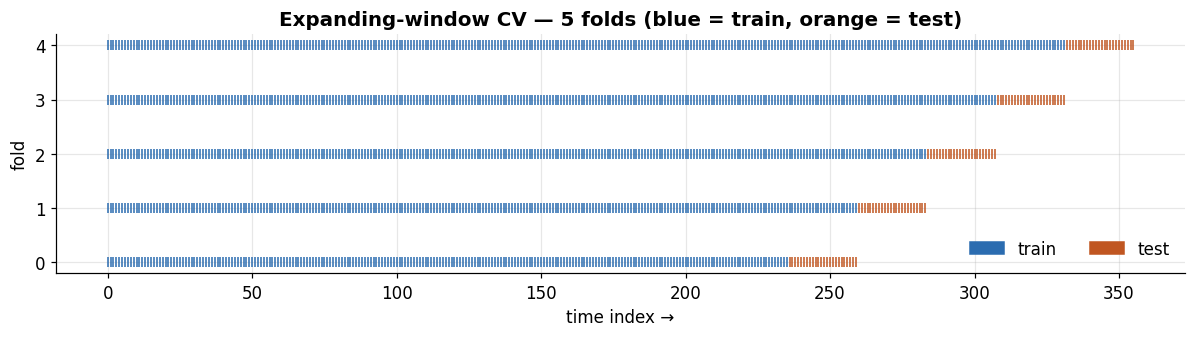

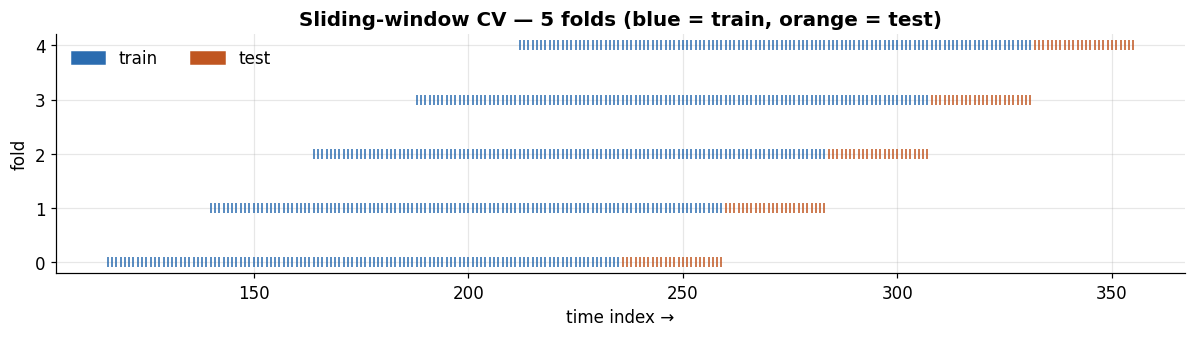

In [9]:
def plot_cv_folds(n=len(y), n_splits=5, test_size=24, window="expanding"):
    fig, ax = plt.subplots(figsize=(11, 3.2))
    splitter = TimeSeriesSplit(n_splits=n_splits, test_size=test_size,
                               max_train_size=(120 if window=="sliding" else None))
    dummy = np.arange(n)
    for i, (tri, tei) in enumerate(splitter.split(dummy)):
        ax.plot(tri, [i]*len(tri), "|", color=PALETTE[0], ms=6)
        ax.plot(tei, [i]*len(tei), "|", color=PALETTE[1], ms=6)
    ax.set_title(f"{window.capitalize()}-window CV — {n_splits} folds "
                 f"(blue = train, orange = test)")
    ax.set_xlabel("time index →"); ax.set_ylabel("fold"); ax.set_yticks(range(n_splits))
    ax.legend(handles=[Patch(color=PALETTE[0], label="train"),
                       Patch(color=PALETTE[1], label="test")], frameon=False, ncol=2)
    plt.tight_layout(); plt.show()

plot_cv_folds(window="expanding")
plot_cv_folds(window="sliding")

In the **expanding** diagram the blue training bar lengthens each fold; in the
**sliding** diagram it stays a fixed width and marches right. Now the payoff: run
a proper backtest and aggregate each model's error **across all folds**, giving a
mean and a spread instead of one fragile number.

In [10]:
def backtest(forecasters, y, n_splits=6, h=12, m=12):
    tscv = TimeSeriesSplit(n_splits=n_splits, test_size=h)
    acc = {name: {"RMSE": [], "MASE": []} for name in forecasters}
    for tri, tei in tscv.split(y):
        tr, te = y.iloc[tri], y.iloc[tei]
        for name, fn in forecasters.items():
            fc = fn(tr, h)
            acc[name]["RMSE"].append(rmse(te, fc))
            acc[name]["MASE"].append(mase(te, fc, tr, m))
    out = []
    for name, d in acc.items():
        out.append({"model": name,
                    "RMSE_mean": round(np.mean(d["RMSE"]), 2),
                    "RMSE_std":  round(np.std(d["RMSE"]), 2),
                    "MASE_mean": round(np.mean(d["MASE"]), 3)})
    return pd.DataFrame(out).sort_values("MASE_mean").reset_index(drop=True)

board = backtest(FORECASTERS, y, n_splits=6, h=12)
board

,model,RMSE_mean,RMSE_std,MASE_mean
0,Drift,6.97,7.39,0.692
1,Naive,7.14,7.71,0.705
2,ARIMA,7.75,7.12,0.773
3,ETS,8.32,6.44,0.825
4,SeasonalNaive,9.36,7.96,0.939


Read this against the single-split verdict from Parts 3–5. Over **six** folds:

- Every model's **MASE < 1**, so all of them beat the in-sample seasonal-naive
  benchmark on average — a far kinder picture than the one unlucky 2020–21 window
  suggested.
- **Drift** still leads, but **ETS and ARIMA are now clearly competitive**, not
  the also-rans they appeared to be. The single split had *defamed* them.
- The **RMSE spread** (`RMSE_std`) is large — confirming numerically that any one
  fold could have told a very different story.

This is the whole lesson of Part 6: the **procedure** changed the conclusion
without changing a single model.

## 5. Leakage traps — how good scores go wrong

Cross-validation only protects you if **no information flows from the future (or
the test set) into training**. Leakage produces scores that look great and
collapse in production. The time-series-specific traps:

1. **Shuffling / random k-fold** — puts future rows in the training set. Always
   forbidden for temporal data.
2. **Features that peek forward** — centered rolling windows, or any feature
   computed with values at or after the prediction time.
3. **Preprocessing fit on all data** — scalers, imputers, feature selection, or
   target encoders fit **before** the split see the test set. Fit them **inside**
   each fold, on training data only.
4. **Lookahead in tuning** — choosing hyperparameters on the same data you report.
5. **No gap** — when features use a k-length window, leave a **purge/embargo** gap
   so train and test don't overlap through the feature.

We demonstrate trap #2 concretely — the same model, honest vs. leaky features.

In [11]:
# honest: trailing rolling mean (ends at t-1). leaky: centered mean (includes t & future)
lags = pd.concat([y.shift(k) for k in range(1, 4)], axis=1); lags.columns = ["lag1","lag2","lag3"]
trailing = y.shift(1).rolling(6).mean().rename("trailing_ma")
centered = y.rolling(7, center=True).mean().rename("centered_ma")   # LEAKS the future

def ts_cv_rmse(Xcols):
    dat = pd.concat([Xcols, y.rename("y")], axis=1).dropna()
    X, yy = dat.iloc[:, :-1], dat["y"]
    errs = [rmse(yy.iloc[te], LinearRegression().fit(X.iloc[tr], yy.iloc[tr]).predict(X.iloc[te]))
            for tr, te in TimeSeriesSplit(n_splits=5).split(X)]
    return np.mean(errs)

honest = ts_cv_rmse(pd.concat([lags, trailing], axis=1))
leaky  = ts_cv_rmse(pd.concat([lags, centered], axis=1))
print(f"Honest features (trailing MA): CV RMSE = {honest:.3f}")
print(f"Leaky  features (centered MA): CV RMSE = {leaky:.3f}")
print(f"=> leakage makes the model look {honest/leaky:.1f}× better than it really is")

Honest features (trailing MA): CV RMSE = 2.497
Leaky  features (centered MA): CV RMSE = 1.566
=> leakage makes the model look 1.6× better than it really is


A centered moving average quietly folds each month's own value (and its
neighbours) into the feature, so the model "predicts" what it has effectively
already seen — CV RMSE drops by a third, an illusion that would evaporate the
moment the model met genuinely future data it can't peek at. The fix is trivial
(use only trailing windows) but the bug is invisible unless you look for it.

> **A note on shuffling.** For purely *backward-looking* lag features the numeric
> penalty from random k-fold can be small (each row still only sees its own past),
> which lulls people into thinking it's fine. It is not: the moment a feature or a
> preprocessing step carries cross-sectional information, random folds leak
> heavily. Use `TimeSeriesSplit`, never `KFold(shuffle=True)`, on temporal data —
> full stop.

## 6. Multi-step forecasting strategies

We've been forecasting 12–24 steps at once. *How* a model produces a multi-step
path matters, especially for the ML models of Part 7 that natively predict only
**one** step. Three strategies:

- **Recursive (iterated)** — train one 1-step model; feed each prediction back in
  as an input to predict the next step. Simple and data-efficient, but **errors
  compound** as predictions feed on predictions.
- **Direct** — train a **separate model for each horizon** h (predict $y_{t+h}$
  directly from time-t features). No error accumulation, but you fit *h* models and
  ignore dependencies between horizons.
- **DirRec** — a hybrid: a model per horizon, but each is allowed to use the
  previous horizons' predictions as extra inputs.

We contrast recursive vs. direct with a simple lag-feature linear model over a
24-month horizon.

Recursive strategy: RMSE = 22.27
Direct    strategy: RMSE = 21.89


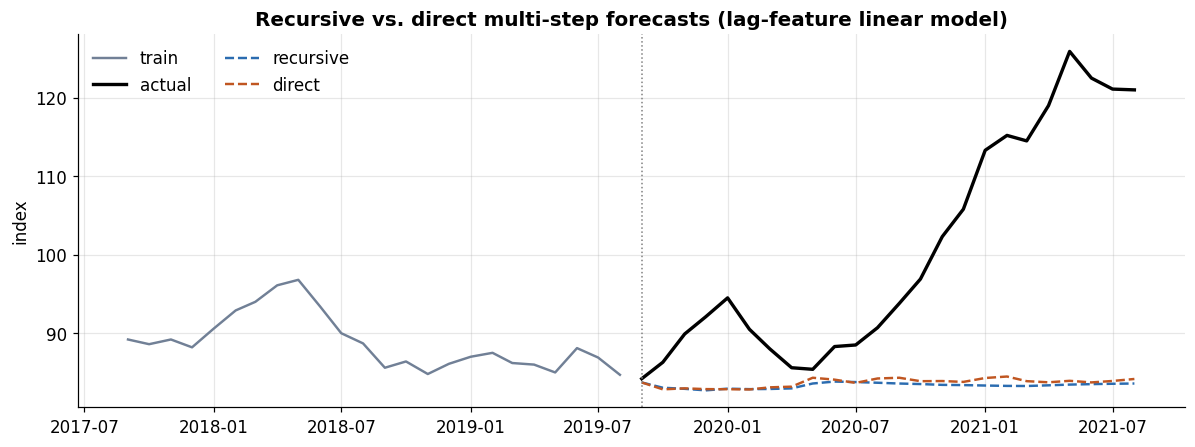

In [12]:
h_test = 24
tr, te = y.iloc[:-h_test], y.iloc[-h_test:]
nlags = 12

# recursive: one 1-step model, iterate
Xr = pd.concat([tr.shift(k) for k in range(1, nlags+1)], axis=1).dropna()
Xr.columns = [f"lag{k}" for k in range(1, nlags+1)]
one_step = LinearRegression().fit(Xr, tr.loc[Xr.index])
hist, rec = list(tr.values), []
for _ in range(h_test):
    feat = np.array(hist[-nlags:][::-1]).reshape(1, -1)
    p = one_step.predict(feat)[0]; rec.append(p); hist.append(p)

# direct: one model per horizon
direct = []
for hz in range(1, h_test+1):
    Xd = pd.concat([tr.shift(k) for k in range(nlags)], axis=1); Xd.columns=[f"l{k}" for k in range(nlags)]
    yd = tr.shift(-hz)
    d = pd.concat([Xd, yd.rename("y")], axis=1).dropna()
    md_ = LinearRegression().fit(d.iloc[:, :-1], d["y"])
    direct.append(md_.predict(tr.iloc[-nlags:].values[::-1].reshape(1, -1))[0])

print(f"Recursive strategy: RMSE = {rmse(te, rec):.2f}")
print(f"Direct    strategy: RMSE = {rmse(te, direct):.2f}")

fig, ax = plt.subplots(figsize=(11, 4.2))
ax.plot(tr.index[-24:], tr.iloc[-24:], color=PALETTE[5], label="train")
ax.plot(te.index, te, color="black", lw=2.2, label="actual")
ax.plot(te.index, rec, color=PALETTE[0], ls="--", label="recursive")
ax.plot(te.index, direct, color=PALETTE[1], ls="--", label="direct")
ax.axvline(te.index[0], color="grey", lw=1, ls=":")
ax.set_title("Recursive vs. direct multi-step forecasts (lag-feature linear model)")
ax.set_ylabel("index"); ax.legend(frameon=False, ncol=2)
plt.tight_layout(); plt.show()

On this hard window the two are close, with **direct** slightly ahead — typical
when the horizon is long enough that recursive error-compounding starts to bite.
There's no universal winner: recursive is simpler and often excellent at short
horizons; direct is safer at long ones but costs *h* models. These strategies are
exactly how we'll turn the regressors of **Part 7** into forecasters.

## 7. Doing this with `sktime`

Rolling your own backtest (as above) is the best way to *understand* it; for
production, **`sktime`** provides tested splitters, metrics, and a unified
forecaster API so you don't re-implement the loop. Its `evaluate` runs a
walk-forward backtest in one call.

In [13]:
from sktime.forecasting.naive import NaiveForecaster
from sktime.forecasting.model_selection import ExpandingWindowSplitter
from sktime.forecasting.model_evaluation import evaluate
from sktime.performance_metrics.forecasting import MeanAbsoluteScaledError

cv = ExpandingWindowSplitter(initial_window=240, step_length=12, fh=list(range(1, 13)))
scorer = MeanAbsoluteScaledError()
sk_out = evaluate(forecaster=NaiveForecaster(strategy="drift"), y=y, cv=cv,
                  scoring=scorer, return_data=False)
print("sktime walk-forward backtest of drift forecaster:")
sk_out[["test_MeanAbsoluteScaledError", "len_train_window", "cutoff"]].round(3)

sktime walk-forward backtest of drift forecaster:


,test_MeanAbsoluteScaledError,len_train_window,cutoff
0,4.861,240,2011-12-01
1,5.459,252,2012-12-01
2,3.086,264,2013-12-01
3,6.745,276,2014-12-01
4,3.308,288,2015-12-01
5,0.919,300,2016-12-01
6,2.236,312,2017-12-01
7,0.885,324,2018-12-01
8,2.775,336,2019-12-01


`sktime` also offers `ForecastingGridSearchCV` (tune within the backtest, no
leakage), a large library of forecasters under one interface, and probabilistic
scoring — worth adopting once the concepts above are second nature.

## 8. Exercises

1. **Fragility elsewhere.** Repeat the Section 1 window sweep for `Rice_Price`. Is
   the single-split score as unstable as for the Food Price Index?
2. **Metric disagreement.** Find a forecaster and window where MAE and RMSE rank
   two models in *opposite* order. What does that tell you about the errors?
3. **Sliding vs expanding.** Re-run the `backtest` with a fixed `max_train_size`
   (sliding). Does limiting history help or hurt on this series?
4. **Purge/embargo.** With a 6-month rolling feature, add a 6-month gap between
   train and test in each fold. Does the honest score change?
5. **Direct vs recursive.** Compare the two strategies at h = 1, 3, 6, 12, 24. At
   what horizon does direct overtake recursive here?

In [14]:
# --- Solution to Exercise 5 (setup) ---
def strat_rmse(h_test):
    tr, te = y.iloc[:-h_test], y.iloc[-h_test:]
    Xr = pd.concat([tr.shift(k) for k in range(1, 13)], axis=1).dropna()
    om = LinearRegression().fit(Xr, tr.loc[Xr.index])
    hist, rec = list(tr.values), []
    for _ in range(h_test):
        rec.append(om.predict(np.array(hist[-12:][::-1]).reshape(1,-1))[0]); hist.append(rec[-1])
    Xd = pd.concat([tr.shift(k) for k in range(12)], axis=1)
    dd = pd.concat([Xd, tr.shift(-h_test).rename("y")], axis=1).dropna()
    dm = LinearRegression().fit(dd.iloc[:, :-1], dd["y"])
    direct_h = dm.predict(tr.iloc[-12:].values[::-1].reshape(1,-1))[0]
    return round(rmse(te, rec),2), round(abs(te.iloc[-1]-direct_h),2)
for hz in [1, 3, 6, 12, 24]:
    r, d = strat_rmse(hz); print(f"h={hz:2d}: recursive RMSE={r:6.2f} | direct |err@h|={d:6.2f}")

h= 1: recursive RMSE=  0.97 | direct |err@h|=  0.97
h= 3: recursive RMSE=  7.51 | direct |err@h|=  7.77
h= 6: recursive RMSE=  7.79 | direct |err@h|= 10.18
h=12: recursive RMSE= 22.28 | direct |err@h|= 27.02
h=24: recursive RMSE= 22.27 | direct |err@h|= 36.83


## 9. Key takeaways

- A **single train/test split is a sample of size one**; on non-stationary data
  the score can swing by 10× depending on the window. Never conclude from one split.
- **Baselines** (naive, seasonal-naive, drift) are the hurdle *and* the anchor —
  the seasonal-naive error is the denominator of **MASE**.
- Choose metrics deliberately: **MAE/RMSE** (scale-dependent), **MAPE/sMAPE**
  (percentage, with asymmetry/zero pitfalls), **MASE** (scale-free, interpretable,
  the recommended default), and **pinball loss** for probabilistic forecasts.
- **Walk-forward cross-validation** (expanding or sliding windows) turns one
  fragile number into a distribution — and here it *reversed* the Parts 3–5
  verdict, showing ETS/ARIMA were competitive all along.
- Guard against **leakage**: no shuffling, no forward-peeking features, fit
  preprocessing inside folds, and purge/embargo around windowed features.
- **Recursive vs. direct vs. DirRec** are the multi-step strategies that turn any
  one-step regressor into a forecaster — the hinge to the machine-learning parts.

### What's next — Part 7: Feature Engineering & the ML Reduction
With rigorous evaluation in hand, Part 7 reframes forecasting as **supervised
learning**: turning a series into a feature matrix (lags, rolling stats, calendar
and Fourier terms, exogenous variables), so that any regressor — and then the
gradient-boosting and deep models of Parts 8–10 — can forecast, *scored with the
backtesting discipline established here.*